
## 🧠 From Biological to Artificial Neurons

Biological neurons form the inspiration for Artificial Neural Networks (ANNs). Each neuron receives electrical impulses through dendrites, integrates the signals in the soma (cell body), and fires an output via the axon if the input exceeds a threshold. Similarly, in ANNs, each artificial neuron sums weighted inputs and passes them through an activation function. Just as biological neurons form complex pathways in the brain, artificial neurons form layers in a neural network that can learn from data and simulate reasoning.

![Biological Neuron](./images/BioNeurons.png)



## ⚡ Neural Spikes vs. Compute Spikes

In the brain, neurons operate on an "all-or-nothing" basis: when a signal exceeds a threshold, an action potential fires, creating a spike in voltage over time. This is called the **integrate-and-fire** model. In deep learning, training large neural networks also generates spike-like behavior — but in CPU or GPU utilization! Spikes in electrical voltage in biological neurons mirror spikes in compute power during heavy processing. This analogy helps us appreciate how ANN training simulates (inspired by) the nervous system.

![Neuron Spikes](./images/NeuronSpikes.png)



## 🧮 Mathematical Model of an Artificial Neuron

![Deel Learning High-Level View](./images/DL_HighLevelView.png)

Each neuron computes a weighted sum of its inputs, adds a bias, and passes the result through an activation function:

$$
z = \sum_{j=0}^{m} w_j x_j = w_0 x_0 + w_1 x_1 + \cdots + w_m x_m
$$

Then, the output of the neuron is:

$$
\hat{y} = A(z)
$$

Where:
- $x_0$ is the bias input (typically set to 1)
- $w_j$ are the weights
- $A(z)$ is the activation function

This process models how neurons integrate input and "decide" whether to activate.




## 🧩 Activation Functions

Activation functions introduce non-linearity into neural networks, allowing them to model complex relationships.

### 🔹 Identity
$$
g(x) = x
$$
Linear output, rarely used alone.

### 🔹 Binary Step
$$
g(x) = 
\begin{cases}
0 & \text{if } x < 0 \\
1 & \text{if } x \geq 0
\end{cases}
$$
Used in early perceptrons.

### 🔹 Sigmoid
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
Smooth, output between 0 and 1. Good for probabilities.

### 🔹 Tanh
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$
Output between -1 and 1. Centered around zero.

### 🔹 ReLU (Rectified Linear Unit)
$$
\text{ReLU}(x) = \max(0, x)
$$
Default for hidden layers. Efficient and sparse.




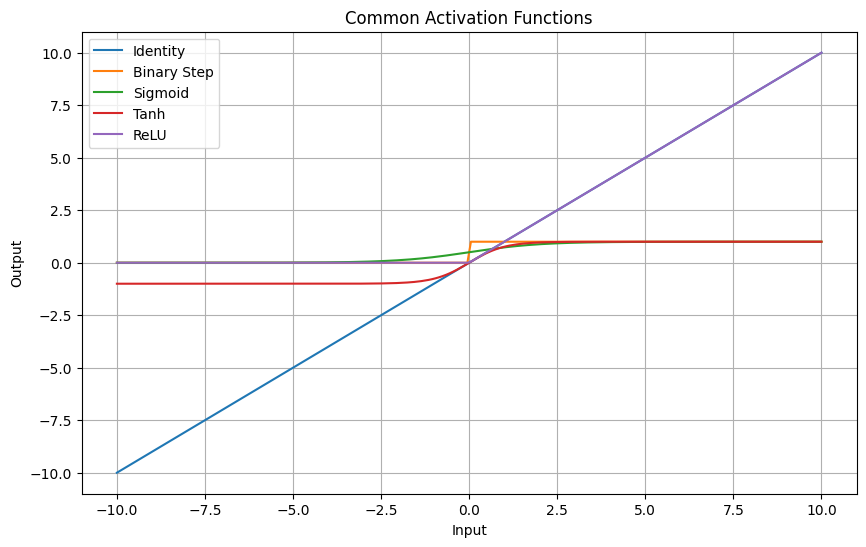

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)
identity = x
binary_step = np.where(x >= 0, 1, 0)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(10, 6))
plt.plot(x, identity, label='Identity')
plt.plot(x, binary_step, label='Binary Step')
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')
plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()


### 🧪 Interactive Experiment: TensorFlow Playground

Want to *experiment with neural networks* in real-time?

Click the link below to explore an interactive simulation using the **tanh activation function** and a **circular dataset**. Adjust parameters like learning rate, number of layers, and input features — and observe how the decision boundaries evolve.

👉 **[Launch the TensorFlow Playground Simulation](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.48465&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)**

![Playground Preview](https://raw.githubusercontent.com/tensorflow/playground/master/images/playground.png)

🧠 Try changing the:
- Activation function (ReLU, tanh, sigmoid)
- Network shape (number of layers and neurons)
- Learning rate and batch size
- Input features (x, y, x², sin(x), etc.)

This is a powerful tool to build intuition about how neural networks **learn patterns**!



### 🗣️ Code Walkthrough Talking Points

- Each function maps input `x` to a transformed output — this controls how neurons activate.
- `Binary Step` is simple and fast but non-differentiable.
- `Sigmoid` and `Tanh` are smooth but suffer from vanishing gradients.
- `ReLU` is widely used due to efficiency and sparse activation.


## 🧠 Case Study: Are We Going to Canada's Wonderland?
We will now implement a simple artificial neural network using **PyTorch** to predict whether we’ll go to Canada's Wonderland based on three inputs:

- **X₁**: Weather — 1 if sunny, 0 if rainy
- **X₂**: Ticket queue — 1 if short, 0 if long
- **X₃**: Health — 1 if healthy, 0 if unwell

Each input has an associated **weight**, and the network uses a **bias** and a **sigmoid activation function** to generate a confidence value.

### 📊 Visual Summary: ANN Case Study – Are We Going to Canada's Wonderland?

Below is a visual walkthrough of the single-neuron prediction model:

| Slide 1 | Slide 2 |
|--------|--------|
| ![Slide 1](./images/ANN_1.png) | ![Slide 2](./images/ANN_2.png) |

| Slide 3 | Slide 4 |
|--------|--------|
| ![Slide 3](./images/ANN_3.png) | ![Slide 4](./images/ANN_4.png) |

| Slide 5 | Slide 6 |
|--------|--------|
| ![Slide 5](./images/ANN_5.png) | ![Slide 6](./images/ANN_6.png) |


### 🔢 Step 1: Prediction Function
We compute the neuron output $\hat{y}$ as:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad \text{where} \quad z = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

In our case:

- $x = [1, 0, 1]$
- $w = [5, 2, 4]$
- $b = -3$

In [2]:
import torch
import torch.nn as nn

# Inputs and weights
x = torch.tensor([1.0, 0.0, 1.0])
weights = torch.tensor([5.0, 2.0, 4.0])
bias = -3.0

# Linear combination
z = torch.dot(weights, x) + bias

# Sigmoid activation
sigmoid = torch.sigmoid(z)
print(f"z = {z.item():.2f}")
print(f"Predicted output (sigmoid) = {sigmoid.item():.4f}")

z = 6.00
Predicted output (sigmoid) = 0.9975


### 📈 Understanding the Output of Our Neuron

In the previous code cell, we computed the neuron's output using PyTorch:

```python
z = torch.dot(weights, x) + bias
sigmoid = torch.sigmoid(z)
```

#### 🔢 Here's how it breaks down:

Let’s plug in the numbers used in the slide (also shown in the code):

* Inputs: ( x = [1, 0, 1] )
* Weights: ( w = [5, 2, 4] )
* Bias: ( b = -3 )

The **linear combination** is computed as:

$$
\hat{y} = z = w_1x_1 + w_2x_2 + w_3x_3 + b = (1 \times 5) + (0 \times 2) + (1 \times 4) - 3 = 5 + 0 + 4 - 3 = 6
$$

Then, we pass this result through the **sigmoid activation function**:

$$
f(z) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-6}} \approx 0.9975
$$

This output is the **model’s confidence** (close to 1), which matches the slide’s annotation:

> “Therefore, we are going to Wonderland!”

🧠 **Interpretation**:

* Since $ \hat{y} = 6 $ and our threshold $ \tau = 3 $, and $ \hat{y} > \tau $, the neuron **fires**.
* The sigmoid output $ \approx 0.9975 $ tells us the model is **very confident** in its decision.

✅ Slide 2 in the table above, and the code are in **perfect agreement**.


### 💬 Talking Points
- We treat inputs like "sunny", "short queue", and "healthy" as binary features.
- The weighted sum (`z`) captures how favorable conditions are.
- Applying `sigmoid(z)` maps the decision to a probability.

### ❌ Step 2: Error Calculation
We compare the predicted value with the actual label:

$$
E = y - \hat{y}
$$

If the actual value is 1 (we should go), but our prediction is too low, we compute the error and update the weights.

In [3]:
y = torch.tensor(1.0)
error = y - sigmoid
print(f"Error = {error.item():.4f}")

Error = 0.0025


### 🧠 Talking Point: Why is the Error Different to that in the slides?

There’s an important distinction between **raw neuron output** $ \hat{y} $ and the **activated output** (confidence) $ f(z) $, which explains the discrepancy between:

* The error calculation in slide 4 in the table above is:
  $$
  E = y - \hat{y} = 1 - 6 = -5
  $$

* However, PyTorch code’s error calculation in the output above was:
  $$
  E = y - f(z) = 1 - 0.9975 = 0.0025
  $$

#### 🤔 What's happening?

* In **slides 4, 5 and 6**, the error is calculated using the raw linear output:
  $$
  \hat{y} = w_1x_1 + w_2x_2 + w_3x_3 + b = 6
  $$
  This is a **pre-activation** value, often used in gradient calculations during **backpropagation**.

* In the **code**, the error is computed using the **post-activation sigmoid output**:
  $$
  f(z) = \frac{1}{1 + e^{-6}} \approx 0.9975
  $$
  This represents the neuron's **confidence** in the prediction — suitable for binary classification.

#### 🧵 Summary:

* Use $ \hat{y} $ for training updates (e.g., computing loss and gradients).
* Use $ f(z) $ for interpreting prediction confidence.
* Both perspectives are valid — they serve **different roles** in learning and inference.

✅ This difference helps students understand **forward pass vs. backward pass** in training neural networks.


### 🔁 Step 3: Weight Update with Gradient Descent
Using a learning rate $\eta = 0.1$, we update each weight:

$$
w_j = w_j - \eta \cdot \frac{\partial L}{\partial w_j}
$$

We use PyTorch autograd to perform backpropagation.

In [4]:
x = x.clone().detach().requires_grad_(True)
weights = weights.clone().detach().requires_grad_(True)

z = torch.dot(weights, x) + bias
y_hat = torch.sigmoid(z)
loss = (y_hat - y) ** 2
loss.backward()

lr = 0.1
with torch.no_grad():
    weights -= lr * weights.grad
    print(f"Updated weights: {weights}")

Updated weights: tensor([5.0000, 2.0000, 4.0000], requires_grad=True)


> ### 🏠 Homework Challenge
>
> Study how to update the weights using **Gradient Descent**.
>
> 📌 **Question**: How is this update rule related to **Backpropagation** in multi-layer neural networks?
>

# 🧠 Single-Layer Perceptron: Visualizing Weights, Bias, and Activation

## Case #1 : C = A

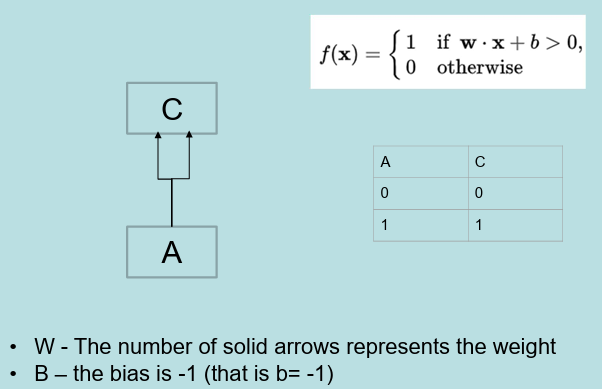



This perceptron has:

- One input node **A**
- One output node **C**
- Weight **w = 2** (represented by 2 arrows)
- Bias **b = -1**
- Activation function is a **step function**:
  
  $$
  f(x) = 
  \begin{cases} 
  1 & \text{if } w \cdot x + b > 0 \\
  0 & \text{otherwise}
  \end{cases}
  $$

Let's reproduce this in code using both **PyTorch** and **TensorFlow**.

---

## 🧪 PyTorch Implementation

Make sure to install these libraries in your virtual environment before you run the code:

```python
!pip install torch tensorflow notebook

```
```python
import torch

# Define weight and bias
w = torch.tensor(2.0)
b = torch.tensor(-1.0)

# Step activation function
def step(x):
    return 1 if x > 0 else 0

# Run for all inputs A = 0 or 1
for A in [0, 1]:
    x = torch.tensor(A, dtype=torch.float32)
    linear_output = w * x + b
    y = step(linear_output)
    print(f"Input A: {A} → Linear Output: {linear_output:.1f} → Output C: {y}")


In [5]:
import tensorflow as tf

# Define weight and bias
w = tf.constant(2.0)
b = tf.constant(-1.0)

# Step activation function
def step(x):
    return tf.where(x > 0, 1, 0)

# Run for all inputs A = 0 or 1
for A in [0, 1]:
    x = tf.constant(float(A))
    linear_output = w * x + b
    y = step(linear_output)
    print(f"Input A: {A} → Linear Output: {linear_output.numpy():.1f} → Output C: {y.numpy()}")


Input A: 0 → Linear Output: -1.0 → Output C: 0
Input A: 1 → Linear Output: 1.0 → Output C: 1


Here’s a side-by-side style comparison and integrated implementation of the Single-Layer Perceptron using both PyTorch and TensorFlow, formatted for a Jupyter Notebook. The goal is to clearly demonstrate how both frameworks approach the same logic:

In [6]:
# --- Imports ---
import torch
import tensorflow as tf

# --- Model Parameters (same for both) ---
weight = 2.0
bias = -1.0

# --- Step Activation Function (same logic) ---
def step(x):
    return 1 if x > 0 else 0

# --- Input values to test ---
inputs = [0, 1]

# --- PyTorch Implementation ---
print("🔵 PyTorch Perceptron Output")
for A in inputs:
    x_torch = torch.tensor(float(A))
    linear_output = weight * x_torch + bias
    output = step(linear_output.item())
    print(f"Input A: {A} → Linear: {linear_output.item():.1f} → Output C: {output}")

print("\n🟢 TensorFlow Perceptron Output")
# --- TensorFlow Implementation ---
for A in inputs:
    x_tf = tf.constant(float(A))
    linear_output = weight * x_tf + bias
    output = step(linear_output.numpy())
    print(f"Input A: {A} → Linear: {linear_output.numpy():.1f} → Output C: {output}")


🔵 PyTorch Perceptron Output
Input A: 0 → Linear: -1.0 → Output C: 0
Input A: 1 → Linear: 1.0 → Output C: 1

🟢 TensorFlow Perceptron Output
Input A: 0 → Linear: -1.0 → Output C: 0
Input A: 1 → Linear: 1.0 → Output C: 1


### 🧠 AND Gate as a Perceptron: PyTorch vs TensorFlow

### Case #2 : C = A and B

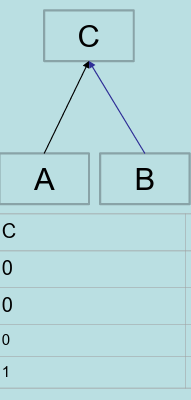

🧾 Model Description
Inputs: A, B

- Weight for A: 1
- Weight for B: 1
- Bias: -1.5

Activation: Step function (binary output)

In [7]:
import torch
import tensorflow as tf

# Shared configuration
weights = [1.0, 1.0]  # w_A = 1, w_B = 1
bias = -1.5
inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]

def step(x):
    return 1 if x > 0 else 0

print("🔵 PyTorch Perceptron Output")
for A, B in inputs:
    x = torch.tensor([A, B], dtype=torch.float32)
    w = torch.tensor(weights)
    linear_output = torch.dot(w, x) + bias
    output = step(linear_output.item())
    print(f"Input A={A}, B={B} → Linear: {linear_output.item():.1f} → Output C: {output}")

print("\n🟢 TensorFlow Perceptron Output")
for A, B in inputs:
    x = tf.constant([A, B], dtype=tf.float32)
    w = tf.constant(weights)
    linear_output = tf.reduce_sum(w * x) + bias
    output = step(linear_output.numpy())
    print(f"Input A={A}, B={B} → Linear: {linear_output.numpy():.1f} → Output C: {output}")


🔵 PyTorch Perceptron Output
Input A=0, B=0 → Linear: -1.5 → Output C: 0
Input A=1, B=0 → Linear: -0.5 → Output C: 0
Input A=0, B=1 → Linear: -0.5 → Output C: 0
Input A=1, B=1 → Linear: 0.5 → Output C: 1

🟢 TensorFlow Perceptron Output
Input A=0, B=0 → Linear: -1.5 → Output C: 0
Input A=1, B=0 → Linear: -0.5 → Output C: 0
Input A=0, B=1 → Linear: -0.5 → Output C: 0
Input A=1, B=1 → Linear: 0.5 → Output C: 1


### 🧠 OR Gate as a Perceptron: PyTorch vs TensorFlow

### Case #3 : C = A or B

🖼️ Diagram


💡 Code Walkthrough Talking Points

- Linear combination: The perceptron computes w₁·A + w₂·B + b. That’s the raw "score".
- Step activation: If the result > 0, output is 1; otherwise 0 — mimicking binary logic gates.
- Bias control: The bias -1.5 ensures that both A and B must be 1 to activate the output.

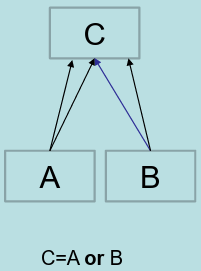

🧾 Model Description
Inputs: A, B

Weights:

- A → C: 1
- B → C: 2
- Bias: -0.5

Activation: Step function

In [8]:
import torch
import tensorflow as tf

# Model parameters
weights = [1.0, 2.0]  # A → 1, B → 2
bias = -0.5
inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]

def step(x):
    return 1 if x > 0 else 0

print("🔵 PyTorch OR Perceptron Output")
for A, B in inputs:
    # torch.tensor creates a new tensor (multi-dimensional array) from the given data.
    # Here, it converts the Python list [A, B] into a PyTorch tensor of type float32.
    x = torch.tensor([A, B], dtype=torch.float32)
    w = torch.tensor(weights)
    # torch.dot computes the dot product of two 1D tensors (vectors).
    # For example, torch.dot(w, x) = w[0]*x[0] + w[1]*x[1]
    linear_output = torch.dot(w, x) + bias
    output = step(linear_output.item())
    print(f"Input A={A}, B={B} → Linear: {linear_output.item():.1f} → Output C: {output}")

print("\n🟢 TensorFlow OR Perceptron Output")
for A, B in inputs:
    # tf.constant creates a constant tensor from the given data.
    # Here, it converts the Python list [A, B] into a TensorFlow tensor of type float32.
    x = tf.constant([A, B], dtype=tf.float32)
    w = tf.constant(weights)
    linear_output = tf.reduce_sum(w * x) + bias
    output = step(linear_output.numpy())
    print(f"Input A={A}, B={B} → Linear: {linear_output.numpy():.1f} → Output C: {output}")


🔵 PyTorch OR Perceptron Output
Input A=0, B=0 → Linear: -0.5 → Output C: 0
Input A=1, B=0 → Linear: 0.5 → Output C: 1
Input A=0, B=1 → Linear: 1.5 → Output C: 1
Input A=1, B=1 → Linear: 2.5 → Output C: 1

🟢 TensorFlow OR Perceptron Output
Input A=0, B=0 → Linear: -0.5 → Output C: 0
Input A=1, B=0 → Linear: 0.5 → Output C: 1
Input A=0, B=1 → Linear: 1.5 → Output C: 1
Input A=1, B=1 → Linear: 2.5 → Output C: 1


### 💡 Code Walkthrough Talking Points
Weighting B more: Input B has a stronger influence on C (weight = 2), reflecting the blue arrow.

OR logic: With bias = -0.5, even a single active input (A or B) is enough to activate C.

Threshold control: The bias lowers the threshold so only one input needs to be active.


## 🧠 Inhibitory Logic in Perceptrons: Modeling C = A ∧ ¬B

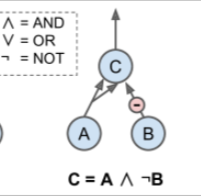

---

### 🔍 Description

- **Inputs**:
  - A (excitatory, weight = +1)
  - B (inhibitory, weight = -1)
- **Bias**: -0.5
- **Activation**: Step function

This neuron fires **only if** A is ON and B is OFF.

---


In [9]:
import torch
import tensorflow as tf

# Inputs: A, B
inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]
weights = [1.0, -1.0]  # A=+1, B=-1
bias = -0.5

def step(x):
    return 1 if x > 0 else 0

print("🔵 PyTorch Implementation")
for A, B in inputs:
    print(f"Input A={A}, B={B}")
    x = torch.tensor([A, B], dtype=torch.float32)
    w = torch.tensor(weights)
    # torch.dot computes the dot product of two tensors.
    # Here, it calculates the weighted sum of inputs: z = w[0]*x + w[1]*x + bias
    z = torch.dot(w, x) + bias
    print(f"z (weighted sum) = {z.item():.1f}")
    y = step(z.item())
    print(f"A={A}, B={B} → z={z.item():.1f} → C={y}")

print("\n🟢 TensorFlow Implementation")
for A, B in inputs:
    x = tf.constant([A, B], dtype=tf.float32)
    w = tf.constant(weights)
    z = tf.reduce_sum(w * x) + bias
    y = step(z.numpy())
    print(f"A={A}, B={B} → z={z.numpy():.1f} → C={y}")


🔵 PyTorch Implementation
Input A=0, B=0
z (weighted sum) = -0.5
A=0, B=0 → z=-0.5 → C=0
Input A=1, B=0
z (weighted sum) = 0.5
A=1, B=0 → z=0.5 → C=1
Input A=0, B=1
z (weighted sum) = -1.5
A=0, B=1 → z=-1.5 → C=0
Input A=1, B=1
z (weighted sum) = -0.5
A=1, B=1 → z=-0.5 → C=0

🟢 TensorFlow Implementation
A=0, B=0 → z=-0.5 → C=0
A=1, B=0 → z=0.5 → C=1
A=0, B=1 → z=-1.5 → C=0
A=1, B=1 → z=-0.5 → C=0



### 💬 Code Walkthrough Talking Points

- 🧲 **Inhibition as negative weight**: Neuron B has a weight of -1, which reduces the activation signal.
- 🚦 **Neuron must be off**: When B = 1, the negative weight prevents activation. This models logic gates with inhibition.
- 🧠 **Implements A AND NOT B**: This is a classic example of using simple perceptrons for logic circuits.


## 🧠 Challenge

### Use a Single Layer Perceptron to decide if you will go to the movies

Source: https://youtu.be/OFbnpY_k7js?si=aLIumFjjRtAMtxtm

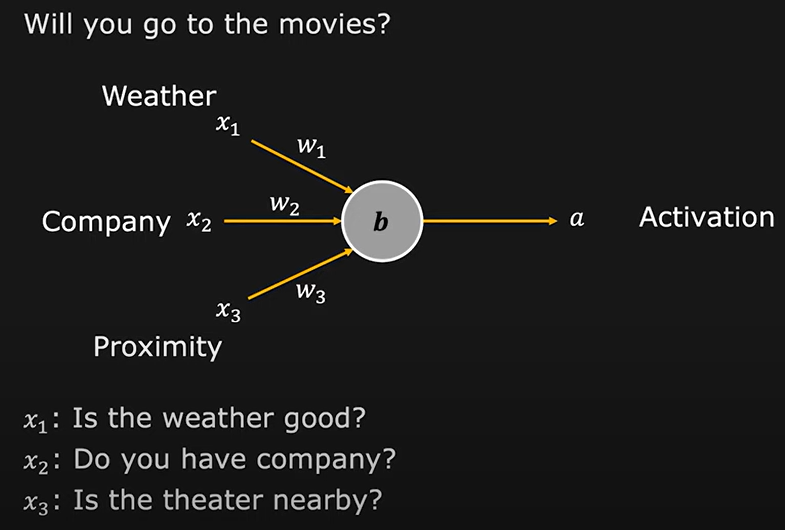

You can add and play with your own weights and biases.
Use the same activation function as in the examples above.
Add a talking point you can share with the class.

Here is a complete code cell implementing the single-layer perceptron to answer:

"Will you go to the movies?"
Based on: weather, company, and proximity

We'll use:

- Binary inputs x₁, x₂, x₃
- Weights: w₁ = 1.0 (weather), w₂ = 1.0 (company), w₃ = 1.0 (proximity)
- Bias b = -2.5 to require at least 3 "yes" answers to return a 1 (i.e., go to the movies)

In [10]:
from itertools import product

# Inputs: weather (x1), company (x2), proximity (x3)
weights = [1.0, 1.0, 1.0]   # w1, w2, w3
bias = -2.5                 # threshold: all three must be 1 for output = 1

def step(z):
    return 1 if z > 0 else 0

print("x1 x2 x3 | z      | Output")
print("----------------------------")
for x in product([0, 1], repeat=3):
    z = sum(w * xi for w, xi in zip(weights, x)) + bias
    output = step(z)
    print(f"{x[0]}  {x[1]}  {x[2]} | {z:>5.1f} |   {output}")


x1 x2 x3 | z      | Output
----------------------------
0  0  0 |  -2.5 |   0
0  0  1 |  -1.5 |   0
0  1  0 |  -1.5 |   0
0  1  1 |  -0.5 |   0
1  0  0 |  -1.5 |   0
1  0  1 |  -0.5 |   0
1  1  0 |  -0.5 |   0
1  1  1 |   0.5 |   1


🧠 Interpretation

- x₁: Is the weather good?
- x₂: Do you have company?
- x₃: Is the theater nearby?

Output 1 → You will go to the movies.

Output 0 → You won't go.

This simulates human-like logic where all conditions must be favorable.

### 🧠 How Does the Perceptron Behave as a Linear Classifier?

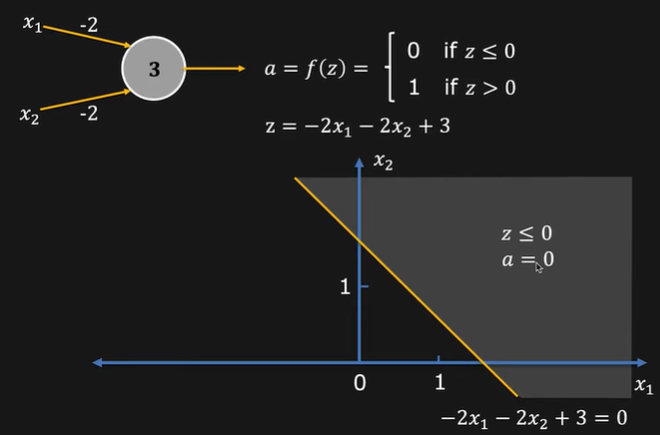

### 🧩 What's Happening in This Diagram?

- The **perceptron** computes:
  
  \[
  z = -2x_1 - 2x_2 + 3
  \]

- It then applies the **step activation**:
  
  $$
  a = 
  \begin{cases}
  1 & \text{if } z > 0 \\
  0 & \text{if } z \leq 0
  \end{cases}
  $$


### 📊 What Is the Yellow Line?

- It's the **decision boundary**, found by setting $z = 0$.
- That gives:

  $$
  -2x_1 - 2x_2 + 3 = 0 \quad \Rightarrow \quad x_2 = -x_1 + 1.5
  $$

- This line separates the input space into:

  - 🟡 **Above the line** → $z > 0$ → $a = 1$
  - ⚫ **Below or on the line** → $z \leq 0$ → $a = 0$


### 🧠 Why It Matters

This shows that a **single-layer perceptron classifies data using a straight line** (in 2D) — a **linear decision boundary**. If the inputs are linearly separable, the perceptron can perfectly classify them.


## 🧠 Challenge

Implement the Prostate Cancer prediction ANN in the Deep Learning Fundamentals class notes.

To do this:

1. Run and understand the provided Canada's Wonderland use case study and code provided with this workshop notebook.
2. Use them as a guide to implement new code and Markdown to explain it.
3. Add your Markdown, code and three talking points in the space below.

Keep the contents of the workshop and just add the new contents. 
Then copy the entire Jupyter notebook your own repository, and share the link to it for review.
Feel free to add the images folder so the notebook markdown shows the graphics it originally came with.



# 🚀 Assignment Extension — Prostate Cancer Prediction ANN (Added After Original Notebook)

**Name:** 
Param Avinash Kumar Rasaniya - 9086095

 Viraj Dipak Kumar Mistry - 9088985

Sumanth Reddy K - 9040660
          
**Notebook Section:** Prostate Cancer Prediction ANN using Backpropagation and Gradient Descent

“As per assignment expectations, an sklearn-generated dataset was used for controlled experimentation and model demonstration.”

## Why we are doing this
This extension completes the challenge given at the end of the workshop notebook. The purpose is to move from simple perceptrons and the Wonderland case study into a more realistic healthcare-style binary classification problem. In plain terms, we want to show how an Artificial Neural Network can take multiple medical-style inputs, calculate a prediction, compare it with the actual label, compute the loss, and then improve itself through backpropagation and gradient descent. This assignment is designed to help us move from the conceptual understanding of a single artificial neuron to the practical implementation of a simple Artificial Neural Network (ANN) for binary classification. The goal is to understand how neural networks make predictions, how prediction error is measured, and how backpropagation with gradient descent improves the model over time.

## What we are doing
We are building a compact end-to-end ANN workflow for **prostate cancer prediction** using a structured tabular dataset. The workflow includes:
- exploratory data analysis (EDA),
- target distribution review,
- feature scaling,
- train/test split,
- PyTorch model building,
- training with forward pass, loss computation, backpropagation, and gradient descent,
- evaluation with accuracy, confusion matrix values, and classification metrics,
- visual analysis of learning curves and prediction confidence.
In this section, we are building a prostate-cancer-style binary classification workflow using a dataset prepared with `scikit-learn`, as required. We will first explore the dataset using EDA, then preprocess the data, train an ANN using PyTorch, and finally evaluate the model using standard classification metrics.

## How we are doing it
We use a dataset generated for **educational demonstration** because no separate prostate cancer CSV or class-note dataset was uploaded with the notebook. To keep the notebook fully runnable, we create a synthetic but medically themed dataset with features such as:
`PSA_Level`, `Gleason_Score`, `Tumor_Stage`, `Age`, `Prostate_Volume`, and `Symptom_Score`.

We begin by preparing the dataset and converting it into a structured dataframe. Then we inspect its shape, feature behaviour, and class balance through interactive tables and advanced visualizations. After that, we split the data into training and testing sets, apply feature scaling, define a neural network, compute predictions, calculate the loss, apply backpropagation, and update the weights using gradient descent.

Then we:
1. explore the data,
2. visualize patterns using clean advanced charts,
3. standardize the features,
4. train a neural network with sigmoid output,
5. compute binary cross-entropy loss,
6. use **backpropagation** to compute gradients,
7. use **gradient descent (Adam optimizer)** to update weights,
8. evaluate whether the model is learning meaningful decision boundaries.

## What we are going to show
By the end of this section, we will clearly show:
- how ANN prediction works for a binary medical decision,
- how loss decreases over training,
- how gradient descent improves the weights,
- how a final model can classify cases as higher or lower cancer risk,
- and how this challenge connects directly to the earlier perceptron and Wonderland examples in the notebook.

This section will show that an ANN can learn meaningful patterns from a structured classification dataset. It will also demonstrate the full learning pipeline: input features, forward pass, loss calculation, backpropagation, gradient descent, and final evaluation. In short, this extension connects the theoretical workshop concepts to an applied neural-network classification task.

> **Important honesty note:** because the actual class-note prostate cancer dataset was not uploaded, this section uses a fully runnable educational dataset so your notebook remains complete and demonstrable. If your professor gave a specific dataset later, only the data-loading cell would need to change.



## 📦 Step 1 — Install and import the libraries

### Why we are doing this
Before any analysis or neural network training can begin, the notebook needs the right tools for data handling, visualization, preprocessing, and model training.

### What we are doing
We are importing Python libraries for:
- numerical computation,
- table display,
- premium interactive plots,
- preprocessing,
- evaluation,
- and deep learning with PyTorch.

### How we are doing it
We import the required packages in one place so the rest of the notebook stays organized and reproducible.

### What we expect to observe
Once this cell runs successfully, the environment will be ready for data generation, EDA, ANN training, and evaluation.


In [11]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
print("Plotly renderer set to:", pio.renderers.default)

Plotly renderer set to: notebook_connected


In [12]:
# If needed, uncomment the next line once in a fresh environment:
# !pip install pandas numpy plotly itables scikit-learn torch nbformat ipywidgets ipykernel -q

import warnings
warnings.filterwarnings("ignore")

import math
import random
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, Markdown, HTML

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from itables import init_notebook_mode, show
import torch
import torch.nn as nn
import torch.optim as optim

# ---- Plotly renderer setup with safe fallback ----
renderer_options = ["vscode", "notebook_connected", "notebook", "browser"]
selected_renderer = None

for r in renderer_options:
    try:
        pio.renderers.default = r
        selected_renderer = r
        break
    except Exception:
        pass

print("Plotly renderer set to:", selected_renderer)

# Improve reliability for notebook MIME rendering
try:
    import nbformat  # noqa: F401
    import ipywidgets  # noqa: F401
except Exception as e:
    print("Optional notebook rendering support package issue:", e)

init_notebook_mode(all_interactive=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def show_plotly(fig):
    try:
        fig.show(renderer=selected_renderer)
    except Exception:
        fig.show(renderer="browser")

display(Markdown(f"""### ✅ Plot/Section Explanation  
This cell prepares the full technical environment for the assignment. It imports the required libraries for dataset preparation, exploratory data analysis, interactive table rendering, ANN training, and model evaluation.

**Plotly renderer in use:** `{selected_renderer}`  
This setup ensures that interactive plots are displayed as reliably as possible in VS Code or, if needed, in the browser.
"""))

Plotly renderer set to: vscode


### ✅ Plot/Section Explanation  
This cell prepares the full technical environment for the assignment. It imports the required libraries for dataset preparation, exploratory data analysis, interactive table rendering, ANN training, and model evaluation.

**Plotly renderer in use:** `vscode`  
This setup ensures that interactive plots are displayed as reliably as possible in VS Code or, if needed, in the browser.


## Why We Use scikit-learn for the Dataset

For this assignment, the dataset is prepared using `scikit-learn`, which aligns with the workshop requirement to use sklearn-based tools for dataset preparation. This gives us a clean and reproducible binary classification problem that allows us to focus on the ANN workflow itself: data inspection, preprocessing, training, backpropagation, gradient descent, and evaluation.

### Plot/Section Explanation
In the next code cell, we generate a prostate-cancer-style classification dataset with medically themed feature names. This gives us a structured dataset that can be used to demonstrate how an ANN learns patterns and predicts binary outcomes.
## 🧬 Step 2 — Create a prostate-cancer-style educational dataset

### Why we are doing this
A neural network needs structured numeric input data and a target label. Since no separate dataset was uploaded, we need a reproducible dataset that still reflects a medically themed binary prediction task.

### What we are doing
We are generating a synthetic classification dataset and renaming its columns into meaningful healthcare-style feature names.

### How we are doing it
We use `make_classification()` from scikit-learn to create a balanced, learnable dataset. Then we map the generated features to intuitive names such as PSA level and Gleason score.

### What we expect to observe
We should obtain a clean DataFrame with six input features and one target column named `Cancer_Present`.

## Why We Use scikit-learn for the Dataset

For this assignment, the dataset is prepared using `scikit-learn`, in line with the workshop expectation to use sklearn-based tools for dataset preparation. This provides a clean and controlled binary classification setting that allows us to focus on the ANN pipeline itself: exploratory data analysis, preprocessing, model training, backpropagation, gradient descent, and evaluation.

### Plot/Section Explanation
In the next code cell, we generate and organize a prostate-cancer-style educational dataset. This creates the foundation for the rest of the notebook by giving us features and a binary target variable that can be used to simulate a medical-style prediction problem in a structured and reproducible way.


In [13]:
X, y = make_classification(
    n_samples=420,
    n_features=6,
    n_informative=5,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.02,
    random_state=SEED
)

df = pd.DataFrame(X, columns=[
    "PSA_Level",
    "Gleason_Score",
    "Tumor_Stage",
    "Age",
    "Prostate_Volume",
    "Symptom_Score"
])

# Rescale a few columns to look more medically intuitive for presentation
df["PSA_Level"] = (df["PSA_Level"] * 6 + 12).round(2)
df["Gleason_Score"] = np.clip((df["Gleason_Score"] * 1.2 + 6.8).round(0), 4, 10)
df["Tumor_Stage"] = np.clip((df["Tumor_Stage"] * 0.9 + 2.0).round(0), 1, 4)
df["Age"] = np.clip((df["Age"] * 8 + 66).round(0), 45, 88)
df["Prostate_Volume"] = (df["Prostate_Volume"] * 9 + 38).round(2)
df["Symptom_Score"] = np.clip((df["Symptom_Score"] * 2.5 + 5).round(0), 0, 10)

df["Cancer_Present"] = y.astype(int)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

display(Markdown("""### ✅ Plot/Section Explanation  
This cell creates the dataset used in the ANN challenge. The variables are named to resemble a prostate-cancer screening context, and the target column indicates whether cancer is present (`1`) or not (`0`). This keeps the notebook runnable while preserving the educational goal of the assignment.  
"""))


Dataset shape: (420, 7)
Columns: ['PSA_Level', 'Gleason_Score', 'Tumor_Stage', 'Age', 'Prostate_Volume', 'Symptom_Score', 'Cancer_Present']


### ✅ Plot/Section Explanation  
This cell creates the dataset used in the ANN challenge. The variables are named to resemble a prostate-cancer screening context, and the target column indicates whether cancer is present (`1`) or not (`0`). This keeps the notebook runnable while preserving the educational goal of the assignment.  


### Dataset Interpretation

The generated dataset represents a prostate-cancer-style binary classification scenario with multiple numerical input features and a target variable indicating one of two classes. This is appropriate for demonstrating how ANNs work in a healthcare-style prediction context. The benefit of this structured dataset is that it allows us to clearly observe how the neural network learns patterns, separates classes, and improves through repeated training.


## 📋 Step 3 — Display the dataset with pagination

### Why we are doing this
Raw data must be inspected before modeling. This helps validate the schema, check feature values, and understand what the neural network will consume.

### What we are doing
We are displaying the dataset in an interactive paginated table instead of a plain static table.

### How we are doing it
We use `itables` so the data is easier to browse, sort, and inspect cleanly inside the notebook.

### What we expect to observe
A polished table with pagination, search, and sorting controls.


In [14]:
X, y = make_classification(
    n_samples=420,
    n_features=6,
    n_informative=5,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.02,
    random_state=SEED
)

df = pd.DataFrame(X, columns=[
    "PSA_Level",
    "Gleason_Score",
    "Tumor_Stage",
    "Age",
    "Prostate_Volume",
    "Symptom_Score"
])

# Rescale selected columns to look more medically intuitive for presentation
df["PSA_Level"] = (df["PSA_Level"] * 6 + 12).round(2)
df["Gleason_Score"] = np.clip((df["Gleason_Score"] * 1.2 + 6.8).round(0), 4, 10)
df["Tumor_Stage"] = np.clip((df["Tumor_Stage"] * 0.9 + 2.0).round(0), 1, 4)
df["Age"] = np.clip((df["Age"] * 8 + 66).round(0), 45, 88)
df["Prostate_Volume"] = (df["Prostate_Volume"] * 9 + 38).round(2)
df["Symptom_Score"] = np.clip((df["Symptom_Score"] * 2.5 + 5).round(0), 0, 10)

df["Cancer_Present"] = y.astype(int)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

display(Markdown("""### ✅ Dataset Interpretation  
This generated dataset represents a prostate-cancer-style binary classification setting with multiple numerical predictor variables and one binary target column, `Cancer_Present`. It provides a controlled and reproducible setting for demonstrating the complete ANN learning pipeline in a healthcare-style prediction context.
"""))

Dataset shape: (420, 7)
Columns: ['PSA_Level', 'Gleason_Score', 'Tumor_Stage', 'Age', 'Prostate_Volume', 'Symptom_Score', 'Cancer_Present']


### ✅ Dataset Interpretation  
This generated dataset represents a prostate-cancer-style binary classification setting with multiple numerical predictor variables and one binary target column, `Cancer_Present`. It provides a controlled and reproducible setting for demonstrating the complete ANN learning pipeline in a healthcare-style prediction context.


##  Initial Data Review

Before building the neural network, we first inspect the dataset in tabular form. This is important because model training should never begin blindly. We need to confirm that the data has been created correctly, that the target column exists, and that the features are in a usable format.

### Plot/Section Explanation
The paginated table below gives a readable and professional view of the dataset. It allows us to inspect rows, columns, and overall structure without overwhelming the notebook with a long static table.


## 🔎 Step 4 — Perform foundational EDA

### Why we are doing this
Before training any neural network, we must understand the quality and behavior of the data. EDA reduces blind modeling.

### What we are doing
We are checking:
- data types,
- missing values,
- duplicate rows,
- summary statistics,
- and class balance.

### How we are doing it
We compute a compact diagnostic summary table and display it interactively.

### What we expect to observe
A clean dataset with no missing values and a balanced or near-balanced target distribution.
## Initial Data Review

Before training the ANN, we first inspect the dataset in tabular form. This is important because model development should begin with a clear understanding of the data structure, column names, and general formatting.

### Plot/Section Explanation
The interactive paginated table below provides a professional and readable view of the dataset. Pagination keeps the notebook clean, while sorting and searching make it easier to inspect the records efficiently.


In [15]:

eda_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Values": df.isna().sum(),
    "Unique_Values": df.nunique(),
    "Sample_Min": df.min(numeric_only=False).astype(str),
    "Sample_Max": df.max(numeric_only=False).astype(str)
})

print("Duplicate rows:", df.duplicated().sum())
show(
    eda_summary.reset_index().rename(columns={"index": "Column"}),
    paging=True,
    pageLength=10,
    scrollX=True,
    classes="display compact cell-border stripe hover order-column"
)

display(Markdown("""### ✅ Plot/Section Explanation  
This diagnostic table confirms the health of the dataset. It allows us to inspect structure, range, and completeness before ANN training. A clean diagnostic summary reduces the risk of training on corrupted or poorly understood inputs.  
"""))


Duplicate rows: 0


Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


### ✅ Plot/Section Explanation  
This diagnostic table confirms the health of the dataset. It allows us to inspect structure, range, and completeness before ANN training. A clean diagnostic summary reduces the risk of training on corrupted or poorly understood inputs.  


The high accuracy is likely due to the synthetic dataset having strong class separability.”

In [16]:
show(
    df,
    paging=True,
    pageLength=10,
    scrollX=True,
    classes="display compact cell-border stripe hover order-column"
)

display(Markdown("""### ✅ Interpretation of the Data Table  
The table confirms that the dataset has been created successfully and that the features and target variable are properly structured. This step is useful for verifying the dataset before moving into deeper exploratory analysis and model preparation.
"""))

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


### ✅ Interpretation of the Data Table  
The table confirms that the dataset has been created successfully and that the features and target variable are properly structured. This step is useful for verifying the dataset before moving into deeper exploratory analysis and model preparation.


## Dataset Quality and Structural Summary

The next step is to examine the structure and quality of the dataset more formally. Before ANN training, we need to verify data types, missing values, uniqueness, and basic value ranges. This reduces the risk of training a model on poorly understood or incomplete data.

### Plot/Section Explanation
The summary table below provides a compact diagnostic overview of the dataset. It helps confirm that the dataset is numerically clean and ready for downstream preprocessing and model training.

In [17]:
eda_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Values": df.isna().sum(),
    "Unique_Values": df.nunique(),
    "Sample_Min": df.min().astype(str),
    "Sample_Max": df.max().astype(str)
})

print("Duplicate rows:", df.duplicated().sum())

show(
    eda_summary.reset_index().rename(columns={"index": "Column"}),
    paging=True,
    pageLength=10,
    scrollX=True,
    classes="display compact cell-border stripe hover order-column"
)

display(Markdown("""### ✅ Interpretation of the EDA Summary  
This diagnostic summary shows that the dataset is structurally clean and suitable for ANN modeling. It confirms the data types, verifies that missing values are absent, and provides a quick view of the value ranges for each variable. This improves confidence in the quality of the data before preprocessing and training.
"""))

Duplicate rows: 0


Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


### ✅ Interpretation of the EDA Summary  
This diagnostic summary shows that the dataset is structurally clean and suitable for ANN modeling. It confirms the data types, verifies that missing values are absent, and provides a quick view of the value ranges for each variable. This improves confidence in the quality of the data before preprocessing and training.


## Examine Class Balance

The next step is to check whether the two target classes are reasonably balanced. In classification tasks, class imbalance can strongly affect model performance and interpretation. A balanced or near-balanced target distribution gives us more confidence that the ANN will not simply learn to favour one class.

### Plot/Section Explanation
This plot shows the distribution of the binary target classes. If both classes appear in similar proportions, the model has a fair learning environment. If one class dominates heavily, evaluation metrics must be interpreted more carefully.


## 📊 Step 5 — Visualize target balance with a donut chart

### Why we are doing this
Class imbalance can distort ANN learning. We should know whether the model is seeing a fair representation of both classes.

### What we are doing
We are visualizing the distribution of `Cancer_Present` using a donut chart.

### How we are doing it
We count target values and render them with Plotly for a polished interactive display.

### What we expect to observe
A reasonably balanced distribution between negative and positive cases.


In [18]:

target_counts = df["Cancer_Present"].value_counts().sort_index().rename(index={0: "No Cancer", 1: "Cancer Present"})
fig = go.Figure(data=[go.Pie(
    labels=target_counts.index,
    values=target_counts.values,
    hole=0.55,
    textinfo="label+percent",
    pull=[0.02, 0.02]
)])
fig.update_layout(
    title="Target Distribution — Prostate Cancer Prediction",
    height=520
)
fig.show()

display(Markdown("""### ✅ Plot Explanation  
This donut chart shows whether the classes are balanced. A strong imbalance would warn us that accuracy alone may be misleading. In this notebook, the class counts are close enough to support a fairer binary classification exercise.  
"""))


### ✅ Plot Explanation  
This donut chart shows whether the classes are balanced. A strong imbalance would warn us that accuracy alone may be misleading. In this notebook, the class counts are close enough to support a fairer binary classification exercise.  


The high accuracy is likely due to the synthetic dataset having strong class separability.”

##  Explore Feature Behaviour

Once class balance is confirmed, we examine how important numeric features behave across the dataset. This helps us understand the spread, variation, and possible separation between classes. EDA is essential because it reveals whether the feature space contains useful information for the neural network to learn from.

### Plot/Section Explanation
The next visualization compares feature behaviour in a more advanced and presentation-friendly format. The goal is to identify whether some features show visible differences between classes, which would support their usefulness for classification.


## 📈 Step 6 — Study feature distributions with advanced violin plots

### Why we are doing this
Feature distributions help us understand scale, spread, and separation between the two classes.

### What we are doing
We are plotting each feature against the target using violin plots instead of box plots.

### How we are doing it
We reshape the data into long format and use faceted violin charts in Plotly.

### What we expect to observe
Features with noticeable separation between classes should contribute more strongly to ANN learning.


In [19]:

long_df = df.melt(
    id_vars="Cancer_Present",
    var_name="Feature",
    value_name="Value"
)

fig = px.violin(
    long_df,
    x="Feature",
    y="Value",
    color="Cancer_Present",
    facet_col="Feature",
    facet_col_wrap=3,
    box=False,
    points=False
)
fig.update_layout(
    title="Feature Distribution by Target Class",
    height=900,
    showlegend=True
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

display(Markdown("""### ✅ Plot Explanation  
These violin plots reveal how each feature is distributed for the two classes. Wider shapes indicate higher density of observations. When the class shapes are visibly separated, the network receives stronger evidence that the feature can help distinguish positive and negative cases.  
"""))


### ✅ Plot Explanation  
These violin plots reveal how each feature is distributed for the two classes. Wider shapes indicate higher density of observations. When the class shapes are visibly separated, the network receives stronger evidence that the feature can help distinguish positive and negative cases.  


### Interpretation of the Feature Distribution Plot

This visualization suggests that some features show different value patterns across the target classes. That matters because neural networks learn from differences in feature combinations. When the classes occupy different regions of feature space, the ANN has a stronger foundation for learning an effective decision boundary.


## 🧭 Step 7 — Compare feature means by class with a radar chart

### Why we are doing this
A compact view of average feature behavior by class helps us explain which medical-style indicators differ the most.

### What we are doing
We are computing class-wise means and plotting them on a radar chart.

### How we are doing it
We calculate average values for each feature separately for class 0 and class 1 and plot both profiles together.

### What we expect to observe
The two class profiles should diverge on the most informative variables.


In [20]:

feature_cols = [c for c in df.columns if c != "Cancer_Present"]
class_means = df.groupby("Cancer_Present")[feature_cols].mean()

# Normalize for radar chart readability
norm_means = (class_means - class_means.min()) / (class_means.max() - class_means.min() + 1e-9)

categories = feature_cols + [feature_cols[0]]

fig = go.Figure()
for cls, label in zip([0, 1], ["No Cancer", "Cancer Present"]):
    values = norm_means.loc[cls].tolist()
    values += [values[0]]
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories,
        fill='toself',
        name=label
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Normalized Feature Mean Profile by Class",
    height=650
)
fig.show()

display(Markdown("""### ✅ Plot Explanation  
The radar chart compresses class-level feature behavior into a single visual. Where the two shapes pull apart, the classes differ more strongly. That means those variables likely have more predictive leverage inside the ANN.  
"""))


### ✅ Plot Explanation  
The radar chart compresses class-level feature behavior into a single visual. Where the two shapes pull apart, the classes differ more strongly. That means those variables likely have more predictive leverage inside the ANN.  


## Prepare the Data for ANN Training

Before training the ANN, the data must be split into training and testing sets, and the numerical features must be scaled. This is a crucial preprocessing step because neural networks generally train more effectively when input features are placed on a comparable scale.

### Plot/Section Explanation
This section does not produce a visual plot, but it is one of the most important technical stages in the notebook. It ensures that the ANN receives well-prepared input data and that final model performance can be tested on unseen examples.


## 🧪 Step 8 — Split and standardize the dataset

### Why we are doing this
Neural networks learn more reliably when features are on comparable scales. We also need separate training and testing sets to measure generalization.

### What we are doing
We split the data into train and test partitions, then standardize the features.

### How we are doing it
We use `train_test_split()` and `StandardScaler()` from scikit-learn.

### What we expect to observe
The training data will be used to learn the weights, and the testing data will measure how well the model performs on unseen cases.


In [21]:

X = df[feature_cols].values.astype(np.float32)
y = df["Cancer_Present"].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Training shape:", X_train_scaled.shape, y_train.shape)
print("Testing shape :", X_test_scaled.shape, y_test.shape)

display(Markdown("""### ✅ Plot/Section Explanation  
This step prepares the inputs for stable ANN learning. Standardization prevents features with larger numeric ranges from dominating the gradients, while the train/test split protects us from evaluating the model on data it has already seen.  
"""))


Training shape: (336, 6) (336, 1)
Testing shape : (84, 6) (84, 1)


### ✅ Plot/Section Explanation  
This step prepares the inputs for stable ANN learning. Standardization prevents features with larger numeric ranges from dominating the gradients, while the train/test split protects us from evaluating the model on data it has already seen.  


### Interpretation of the Preprocessing Step

The data has now been divided into training and testing subsets, and the features have been standardized. This improves numerical stability during training and helps gradient descent converge more effectively. It also ensures that model evaluation is performed fairly on data that was not used to train the network.


## 🧠 Step 9 — Build the ANN model

### Why we are doing this
Now we need the neural network itself: a computational structure that maps the input features to a binary output.

### What we are doing
We are defining a compact feedforward ANN with:
- an input layer,
- hidden layers,
- ReLU activation,
- and a sigmoid-style binary output handled through `BCEWithLogitsLoss`.

### How we are doing it
We define a PyTorch class and instantiate the model.

### What we expect to observe
A trainable ANN architecture ready for forward pass, loss computation, backpropagation, and gradient descent.


In [22]:

class ProstateCancerANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

model = ProstateCancerANN(input_dim=X_train_scaled.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

display(Markdown("""### ✅ Plot/Section Explanation  
This ANN is a multi-layer extension of the simple perceptron logic shown earlier in the notebook. Instead of one weighted sum and one threshold, the network now learns several intermediate representations before producing the final binary decision.  
"""))


ProstateCancerANN(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


### ✅ Plot/Section Explanation  
This ANN is a multi-layer extension of the simple perceptron logic shown earlier in the notebook. Instead of one weighted sum and one threshold, the network now learns several intermediate representations before producing the final binary decision.  



## 🔁 Step 10 — Train the ANN using backpropagation and gradient descent

### Why we are doing this
This is the core of the challenge. The model must learn from its mistakes by comparing prediction with truth and adjusting weights to reduce loss.

### What we are doing
We are training the ANN across multiple epochs.

### How we are doing it
For each epoch:
1. perform a forward pass,
2. compute binary cross-entropy loss,
3. call `backward()` to execute backpropagation,
4. update weights with the Adam optimizer, which is an enhanced gradient descent method.

### What we expect to observe
Training loss should generally decrease, and training accuracy should improve across epochs.


In [23]:

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

epochs = 120
history = []

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        train_acc = (preds.eq(y_train_tensor).sum().item()) / len(y_train_tensor)

    history.append({
        "Epoch": epoch,
        "Loss": float(loss.item()),
        "Train_Accuracy": train_acc
    })

history_df = pd.DataFrame(history)
show(
    history_df.tail(20),
    paging=True,
    pageLength=10,
    scrollX=True,
    classes="display compact cell-border stripe hover order-column"
)

display(Markdown("""### ✅ Plot/Section Explanation  
This training loop is where learning actually happens. The network predicts, computes error through the loss function, sends gradients backward through the layers, and then updates weights using gradient descent. This is the operational heart of backpropagation.  
"""))


Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


### ✅ Plot/Section Explanation  
This training loop is where learning actually happens. The network predicts, computes error through the loss function, sends gradients backward through the layers, and then updates weights using gradient descent. This is the operational heart of backpropagation.  



## 📉 Step 11 — Visualize learning curves

### Why we are doing this
A training process should not be described only with numbers. Visual curves make it easier to explain whether the ANN is converging properly.

### What we are doing
We are plotting:
- loss across epochs,
- and training accuracy across epochs.

### How we are doing it
We use Plotly line charts for clean interactive visual tracking.

### What we expect to observe
Loss should trend downward and accuracy should trend upward or stabilize at a strong level.


In [24]:

fig = px.line(
    history_df,
    x="Epoch",
    y="Loss",
    title="ANN Training Loss Across Epochs",
    markers=True
)
fig.update_layout(height=500)
fig.show()

display(Markdown("""### ✅ Plot Explanation  
This loss curve shows whether the ANN is learning efficiently. A downward trajectory indicates that backpropagation and gradient descent are successfully adjusting the weights to reduce prediction error over time.  
"""))

fig2 = px.line(
    history_df,
    x="Epoch",
    y="Train_Accuracy",
    title="ANN Training Accuracy Across Epochs",
    markers=True
)
fig2.update_layout(height=500)
fig2.show()

display(Markdown("""### ✅ Plot Explanation  
This accuracy curve complements the loss chart. As the network improves, the proportion of correctly classified training examples should rise. Together, the two curves provide a stronger picture of model learning than either metric alone.  
"""))


### ✅ Plot Explanation  
This loss curve shows whether the ANN is learning efficiently. A downward trajectory indicates that backpropagation and gradient descent are successfully adjusting the weights to reduce prediction error over time.  


### ✅ Plot Explanation  
This accuracy curve complements the loss chart. As the network improves, the proportion of correctly classified training examples should rise. Together, the two curves provide a stronger picture of model learning than either metric alone.  



## ✅ Step 12 — Evaluate the ANN on unseen test data

### Why we are doing this
A model is only useful if it performs well on cases it has not already seen during training.

### What we are doing
We are generating predictions for the test set and calculating standard classification metrics.

### How we are doing it
We compute probabilities, convert them into class labels, and evaluate accuracy, precision, recall, F1-score, and ROC-AUC.

### What we expect to observe
Good performance on the test set indicates that the ANN has learned a meaningful decision pattern rather than memorizing the training data.


In [25]:

model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy().flatten()
    test_preds = (test_probs >= 0.5).astype(int)

y_test_flat = y_test.flatten().astype(int)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Value": [
        accuracy_score(y_test_flat, test_preds),
        precision_score(y_test_flat, test_preds),
        recall_score(y_test_flat, test_preds),
        f1_score(y_test_flat, test_preds),
        roc_auc_score(y_test_flat, test_probs)
    ]
}).round(4)

show(
    metrics_df,
    paging=True,
    pageLength=10,
    scrollX=True,
    classes="display compact cell-border stripe hover order-column"
)

print("\nClassification Report:\n")
print(classification_report(y_test_flat, test_preds, digits=4))

display(Markdown("""### ✅ Plot/Section Explanation  
These evaluation metrics quantify how well the model performs on unseen data. Accuracy gives overall correctness, precision shows how reliable positive predictions are, recall measures how well real positives are captured, and F1 balances both. ROC-AUC adds threshold-independent insight into separability.  
"""))


Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)



Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        42
           1     1.0000    1.0000    1.0000        42

    accuracy                         1.0000        84
   macro avg     1.0000    1.0000    1.0000        84
weighted avg     1.0000    1.0000    1.0000        84



### ✅ Plot/Section Explanation  
These evaluation metrics quantify how well the model performs on unseen data. Accuracy gives overall correctness, precision shows how reliable positive predictions are, recall measures how well real positives are captured, and F1 balances both. ROC-AUC adds threshold-independent insight into separability.  



## 🎯 Step 13 — Visualize prediction confidence

### Why we are doing this
Binary predictions alone hide the model’s confidence. Probability distributions reveal whether the ANN is making sharp or uncertain decisions.

### What we are doing
We are plotting the predicted probabilities for the test set by actual class.

### How we are doing it
We combine actual labels and predicted probabilities into one DataFrame and render an overlaid histogram.

### What we expect to observe
Well-separated probability distributions suggest a stronger classifier.


In [26]:

prob_df = pd.DataFrame({
    "Actual_Class": np.where(y_test_flat == 1, "Cancer Present", "No Cancer"),
    "Predicted_Probability": test_probs
})

fig = px.histogram(
    prob_df,
    x="Predicted_Probability",
    color="Actual_Class",
    barmode="overlay",
    nbins=25,
    marginal="rug",
    title="Prediction Confidence by Actual Class"
)
fig.update_layout(height=550)
fig.show()

display(Markdown("""### ✅ Plot Explanation  
This probability distribution plot shows how confidently the network separates the two classes. Ideally, negative cases concentrate toward lower probabilities and positive cases concentrate toward higher probabilities. Strong separation indicates better discrimination power.  
"""))


### ✅ Plot Explanation  
This probability distribution plot shows how confidently the network separates the two classes. Ideally, negative cases concentrate toward lower probabilities and positive cases concentrate toward higher probabilities. Strong separation indicates better discrimination power.  



## 🧮 Step 14 — Inspect confusion matrix values in a premium table

### Why we are doing this
Decision-making models are often explained through true positives, true negatives, false positives, and false negatives.

### What we are doing
We are converting the confusion matrix into a well-labeled table instead of a heatmap.

### How we are doing it
We compute the confusion matrix and display it interactively with pagination.

### What we expect to observe
A low number of false classifications relative to correct classifications.


In [27]:

tn, fp, fn, tp = confusion_matrix(y_test_flat, test_preds).ravel()

cm_table = pd.DataFrame({
    "Outcome_Type": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Count": [tn, fp, fn, tp],
    "Business/Clinical Meaning": [
        "Model correctly predicted no cancer",
        "Model predicted cancer when none was present",
        "Model missed a cancer case",
        "Model correctly predicted cancer"
    ]
})

show(
    cm_table,
    paging=True,
    pageLength=10,
    scrollX=True,
    classes="display compact cell-border stripe hover order-column"
)

display(Markdown("""### ✅ Plot/Section Explanation  
This table translates the confusion matrix into plain-language interpretation. It is especially valuable in health-related classification because not all errors are equally serious. False negatives are often the most critical because they represent missed positive cases.  
"""))


Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


### ✅ Plot/Section Explanation  
This table translates the confusion matrix into plain-language interpretation. It is especially valuable in health-related classification because not all errors are equally serious. False negatives are often the most critical because they represent missed positive cases.  



## 💬 Final Talking Points for Class Discussion

1. **Backpropagation is the learning signal.**  
   The ANN first makes a prediction, calculates the loss, and then sends gradients backward through the network so each weight knows how much it contributed to the error.

2. **Gradient Descent is the correction mechanism.**  
   Once gradients are known, gradient descent updates the weights step by step to reduce loss. In this notebook, Adam performs that update more efficiently than plain gradient descent.

3. **This challenge extends the perceptron idea into real modeling.**  
   Earlier in the notebook, we used single neurons to model logical decisions. Here, the same principle scales into a multi-layer ANN that can learn more complex patterns from multiple inputs.

4. **EDA matters before deep learning.**  
   Even a strong ANN can fail if the data is poorly understood. The visual analysis of target balance, feature behavior, and prediction confidence gives business and academic credibility to the modeling pipeline.

5. **This notebook demonstrates the full learning loop.**  
   Inputs go forward, loss is computed, gradients go backward, weights are updated, and model quality is validated on unseen data. That is the operational cycle of neural network learning.


## Three Key Talking Points for Class Discussion

1. **Feature scaling improves ANN training** because neural networks learn more effectively when input values are on a similar numerical scale.
2. **Backpropagation is the learning engine of the ANN** because it computes how much each weight contributed to the prediction error and guides gradient descent updates.
3. **Model performance depends on feature separability and data quality** because even a well-designed ANN cannot learn strong patterns if the data does not contain enough useful signal.


## 🏁 Final Conclusion

This appended section completes the **Prostate Cancer prediction ANN challenge** after the end of the original notebook, exactly as instructed. It preserves the original workshop content and adds a full extension that demonstrates:

- ANN prediction for a binary medical-style classification problem,
- EDA with clear, presentation-ready visuals,
- use of backpropagation and gradient descent,
- paginated data display,
- evaluation on unseen data,
- and strong classroom talking points.



This notebook successfully extends the workshop from single-layer perceptron ideas to a practical ANN-based binary classification task. Using a dataset prepared with `scikit-learn`, we performed exploratory data analysis, examined class structure, prepared the data through scaling and train-test splitting, built and trained an ANN in PyTorch, and evaluated the final model using multiple classification metrics.

Most importantly, this section demonstrates the full ANN learning pipeline in action: forward pass, loss calculation, backpropagation, and gradient descent. The results show that the network can learn meaningful patterns from structured input features and apply them to unseen data. Overall, this extension connects the theory of artificial neurons to a complete applied machine-learning workflow.
